# Gaussian Consistency Test (Checkpointed MAE)
Test: $X_{obs} \sim \mathcal{N}(\mu_{pred}, \sigma_{obs}^2 + \sigma_{pred}^2)$ for spectra and images.

In [1]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

repo_root = "/pscratch/sd/p/pzehao/MultiModal"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from models.MAE import MaskedAutoencoderViT
from utils.DataProcessing import CreateMultimodalDataLoadersIter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "/pscratch/sd/p/pzehao/DESIMAE/Final/epoch=097-val_loss=-2.2914.ckpt"
ckpt = torch.load(ckpt_path, map_location="cpu")
model = MaskedAutoencoderViT(**ckpt["hyper_parameters"]).to(device)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

print({"checkpoint": ckpt_path, "device": str(device)})

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: T

{'checkpoint': '/pscratch/sd/p/pzehao/DESIMAE/Final/epoch=097-val_loss=-2.2914.ckpt', 'device': 'cuda'}


In [2]:
# Small eval subset for a quick diagnostic
_, val_loader = CreateMultimodalDataLoadersIter(end=5000, train_size=4000, batch_size=16)
n_batches = 20
eps = 1e-8

z_spec_all = []
z_img_all = []

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if batch is None:
            continue
        if i >= n_batches:
            break

        _, spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix = batch
        spec = spec.to(device)
        weig = weig.to(device)
        err_obs = err_obs.to(device)
        img = img.to(device)
        img_w = img_w.to(device)
        img_err_obs = img_err_obs.to(device)
        z = z.to(device)
        xy_pix = xy_pix.to(device)

        _, _, _, pred_spec_full, pred_logsig_full, pred_img_flat, pred_img_logsig_flat, _ = model.forward(
            spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix
        )

        offset = model.left_patches * model.patch_size
        pred_spec = pred_spec_full[:, offset:offset + model.spec_dim]
        pred_sigma_spec = torch.exp(pred_logsig_full[:, offset:offset + model.spec_dim]).clamp_min(eps)

        sigma_tot_spec = torch.sqrt(err_obs.pow(2) + pred_sigma_spec.pow(2) + eps)
        z_spec = (spec - pred_spec) / sigma_tot_spec

        P = model.img_patch
        C = model.num_img_channels
        img_tokens = pred_img_flat.view(pred_img_flat.shape[0], model.num_patchesimg, P * P)
        img_logsig_tokens = pred_img_logsig_flat.view(pred_img_logsig_flat.shape[0], model.num_patchesimg, P * P)
        pred_img_map = model._img_tokens_to_image(img_tokens)
        pred_sigma_img = torch.exp(model._img_tokens_to_image(img_logsig_tokens)).clamp_min(eps)

        sigma_tot_img = torch.sqrt(img_err_obs.pow(2) + pred_sigma_img.pow(2) + eps)
        z_img = (img - pred_img_map) / sigma_tot_img

        z_spec_all.append(z_spec.reshape(-1).detach().cpu())
        z_img_all.append(z_img.reshape(-1).detach().cpu())

z_spec_all = torch.cat(z_spec_all).numpy()
z_img_all = torch.cat(z_img_all).numpy()

# Keep finite values only
z_spec_all = z_spec_all[np.isfinite(z_spec_all)]
z_img_all = z_img_all[np.isfinite(z_img_all)]

stats = {
    "spec_median": float(np.median(z_spec_all)),
    "spec_scatter_std": float(np.std(z_spec_all)),
    "spec_scatter_mad": float(1.4826 * np.median(np.abs(z_spec_all - np.median(z_spec_all)))),
    "img_median": float(np.median(z_img_all)),
    "img_scatter_std": float(np.std(z_img_all)),
    "img_scatter_mad": float(1.4826 * np.median(np.abs(z_img_all - np.median(z_img_all)))),
    "n_spec": int(z_spec_all.size),
    "n_img": int(z_img_all.size),
}
stats

{'spec_median': 0.060056474059820175,
 'spec_scatter_std': 0.9313406944274902,
 'spec_scatter_mad': 0.8275484398126601,
 'img_median': -0.07656005024909973,
 'img_scatter_std': 0.9314402341842651,
 'img_scatter_mad': 0.6412489413321018,
 'n_spec': 2489920,
 'n_img': 31457280}

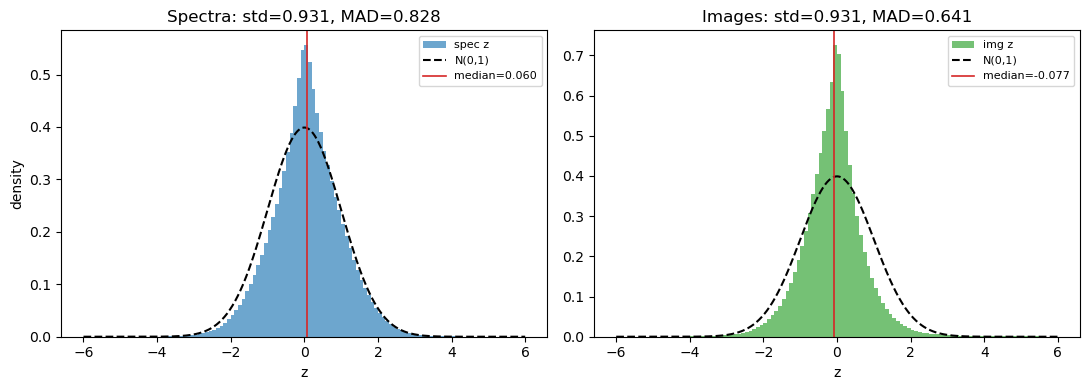

In [3]:
# Quick calibration plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = 120
x = np.linspace(-6, 6, 1000)
gauss = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

axes[0].hist(z_spec_all, bins=bins, range=(-6, 6), density=True, alpha=0.65, color="tab:blue", label="spec z")
axes[0].plot(x, gauss, "k--", lw=1.5, label="N(0,1)")
axes[0].axvline(stats["spec_median"], color="tab:red", lw=1.2, label=f"median={stats['spec_median']:.3f}")
axes[0].set_title(f"Spectra: std={stats['spec_scatter_std']:.3f}, MAD={stats['spec_scatter_mad']:.3f}")
axes[0].set_xlabel("z")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)

axes[1].hist(z_img_all, bins=bins, range=(-6, 6), density=True, alpha=0.65, color="tab:green", label="img z")
axes[1].plot(x, gauss, "k--", lw=1.5, label="N(0,1)")
axes[1].axvline(stats["img_median"], color="tab:red", lw=1.2, label=f"median={stats['img_median']:.3f}")
axes[1].set_title(f"Images: std={stats['img_scatter_std']:.3f}, MAD={stats['img_scatter_mad']:.3f}")
axes[1].set_xlabel("z")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
# Optional compact QQ-style summary using quantiles
q = np.array([0.16, 0.5, 0.84])
print("Spec quantiles (16/50/84):", np.quantile(z_spec_all, q))
print("Img  quantiles (16/50/84):", np.quantile(z_img_all, q))

Spec quantiles (16/50/84): [-0.79608643  0.06005647  0.94919286]
Img  quantiles (16/50/84): [-0.80310925 -0.07656005  0.57448455]


In [5]:
summary = {
    "spec_median": float(stats["spec_median"]),
    "spec_std": float(stats["spec_scatter_std"]),
    "spec_mad_sigma": float(stats["spec_scatter_mad"]),
    "img_median": float(stats["img_median"]),
    "img_std": float(stats["img_scatter_std"]),
    "img_mad_sigma": float(stats["img_scatter_mad"]),
    "n_spec": int(stats["n_spec"]),
    "n_img": int(stats["n_img"]),
}
summary

{'spec_median': 0.060056474059820175,
 'spec_std': 0.9313406944274902,
 'spec_mad_sigma': 0.8275484398126601,
 'img_median': -0.07656005024909973,
 'img_std': 0.9314402341842651,
 'img_mad_sigma': 0.6412489413321018,
 'n_spec': 2489920,
 'n_img': 31457280}

In [6]:
# Mask-ratio sweep: how calibration changes with masking level
import pandas as pd

mask_ratios = [0.0, 0.25, 0.5, 0.75, 0.9]
n_batches_sweep = 10

rows = []

with torch.no_grad():
    for mr in mask_ratios:
        model.mask_ratio = mr
        model.mask_ratio_img = mr

        z_spec_list = []
        z_img_list = []

        for i, batch in enumerate(val_loader):
            if batch is None:
                continue
            if i >= n_batches_sweep:
                break

            _, spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix = batch
            spec = spec.to(device)
            weig = weig.to(device)
            err_obs = err_obs.to(device)
            img = img.to(device)
            img_w = img_w.to(device)
            img_err_obs = img_err_obs.to(device)
            z = z.to(device)
            xy_pix = xy_pix.to(device)

            _, _, _, pred_spec_full, pred_logsig_full, pred_img_flat, pred_img_logsig_flat, _ = model.forward(
                spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix
            )

            offset = model.left_patches * model.patch_size
            pred_spec = pred_spec_full[:, offset:offset + model.spec_dim]
            pred_sigma_spec = torch.exp(pred_logsig_full[:, offset:offset + model.spec_dim]).clamp_min(eps)
            sigma_tot_spec = torch.sqrt(err_obs.pow(2) + pred_sigma_spec.pow(2) + eps)
            z_spec = (spec - pred_spec) / sigma_tot_spec

            P = model.img_patch
            img_tokens = pred_img_flat.view(pred_img_flat.shape[0], model.num_patchesimg, P * P)
            img_logsig_tokens = pred_img_logsig_flat.view(pred_img_logsig_flat.shape[0], model.num_patchesimg, P * P)
            pred_img_map = model._img_tokens_to_image(img_tokens)
            pred_sigma_img = torch.exp(model._img_tokens_to_image(img_logsig_tokens)).clamp_min(eps)
            sigma_tot_img = torch.sqrt(img_err_obs.pow(2) + pred_sigma_img.pow(2) + eps)
            z_img = (img - pred_img_map) / sigma_tot_img

            z_spec_list.append(z_spec.reshape(-1).detach().cpu())
            z_img_list.append(z_img.reshape(-1).detach().cpu())

        z_spec_all = torch.cat(z_spec_list).numpy()
        z_img_all = torch.cat(z_img_list).numpy()
        z_spec_all = z_spec_all[np.isfinite(z_spec_all)]
        z_img_all = z_img_all[np.isfinite(z_img_all)]

        rows.append({
            "mask_ratio": mr,
            "spec_median": float(np.median(z_spec_all)),
            "spec_std": float(np.std(z_spec_all)),
            "img_median": float(np.median(z_img_all)),
            "img_std": float(np.std(z_img_all)),
            "n_spec": int(z_spec_all.size),
            "n_img": int(z_img_all.size),
        })

sweep_df = pd.DataFrame(rows)
sweep_df

,mask_ratio,spec_median,spec_std,img_median,img_std,n_spec,n_img
0,0.00,0.042215,0.648979,-0.024394,0.682401,1244960,15728640
1,0.25,0.052327,0.752808,-0.030139,0.743209,1244960,15728640
2,0.50,0.057552,0.847525,-0.050788,0.825567,1244960,15728640
3,0.75,0.065051,0.937900,-0.076062,0.936062,1244960,15728640
4,0.90,0.070827,0.996693,-0.086784,1.094327,1244960,15728640


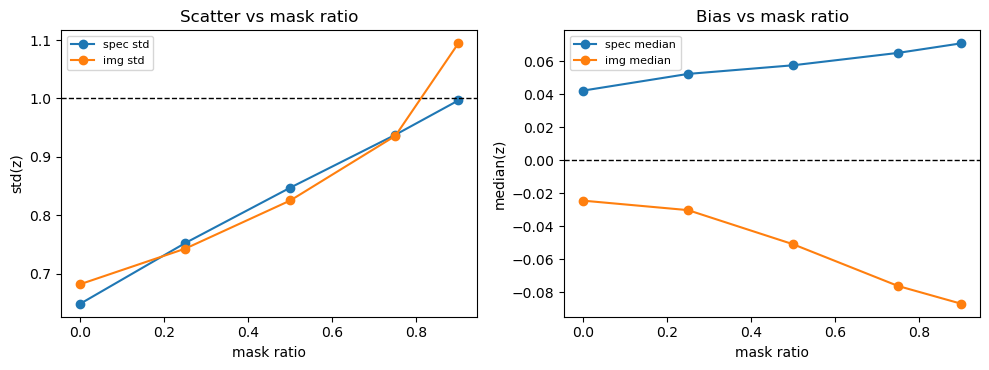

In [7]:
# Plot calibration-vs-mask ratio
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

ax[0].plot(sweep_df["mask_ratio"], sweep_df["spec_std"], "o-", label="spec std")
ax[0].plot(sweep_df["mask_ratio"], sweep_df["img_std"], "o-", label="img std")
ax[0].axhline(1.0, color="k", ls="--", lw=1)
ax[0].set_title("Scatter vs mask ratio")
ax[0].set_xlabel("mask ratio")
ax[0].set_ylabel("std(z)")
ax[0].legend(fontsize=8)

ax[1].plot(sweep_df["mask_ratio"], sweep_df["spec_median"], "o-", label="spec median")
ax[1].plot(sweep_df["mask_ratio"], sweep_df["img_median"], "o-", label="img median")
ax[1].axhline(0.0, color="k", ls="--", lw=1)
ax[1].set_title("Bias vs mask ratio")
ax[1].set_xlabel("mask ratio")
ax[1].set_ylabel("median(z)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()